In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = "raw_data/train.csv"
df = pd.read_csv(path)

In [3]:
df.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [4]:
df["training_program"].value_counts()

training_program
Beginner        39983
Intermediate    25287
Advanced        14730
Name: count, dtype: int64

In [5]:
df["marathon_weather"].value_counts()

marathon_weather
Cloudy    20054
Sunny     20045
Rainy     11955
Hot       11921
Cold       8040
Windy      7985
Name: count, dtype: int64

In [6]:
df["course_difficulty"].value_counts()

course_difficulty
Flat     31849
Mixed    24178
Hilly    23973
Name: count, dtype: int64

In [7]:
df["injury_severity"].value_counts()

injury_severity
Minor       16958
Moderate     9909
Severe       5783
Name: count, dtype: int64

In [8]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

In [9]:
df.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,...,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
count,80000.000000,80000.000000,80000.000000,80000.000000,69255.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,78011.000000,80000.000000,80000.000000
mean,41.538412,36.147413,2.004700,5.505575,259.321580,29.940183,17.225917,4.356975,15.828567,0.978862,...,34.382600,29.235175,64.490900,40.010475,60.272625,52.179725,249.308687,287.931407,6.372187,0.450000
std,13.848164,35.453932,1.419094,2.871288,33.778153,17.392518,7.072490,0.896649,2.358518,0.645074,...,24.113435,21.936089,17.171607,28.388266,20.957232,24.647479,30.372115,33.648005,2.067061,0.804679
min,18.000000,6.000000,0.000000,1.000000,132.000000,20.000000,12.400000,3.000000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,171.000000,1.000000,0.000000
25%,30.000000,10.000000,1.000000,3.000000,236.000000,20.000000,12.400000,4.000000,15.000000,1.000000,...,15.000000,11.000000,53.000000,16.000000,46.000000,35.000000,228.000000,265.000000,5.000000,0.000000
50%,42.000000,25.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,...,33.000000,28.000000,65.000000,39.000000,61.000000,52.000000,252.000000,290.000000,7.000000,0.000000
75%,54.000000,49.000000,3.000000,8.000000,283.000000,34.300000,20.500000,5.000000,15.000000,1.000000,...,51.000000,45.000000,77.000000,61.000000,75.000000,70.000000,272.000000,313.000000,8.000000,1.000000
max,65.000000,240.000000,11.000000,10.000000,377.000000,119.994348,60.200000,7.000000,41.200000,3.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,350.000000,400.000000,10.000000,3.000000


In [10]:
df_prep = df.copy()

In [11]:
# Create dnf from null values 
df_prep['dnf'] = df_prep['actual_finish_time_minutes'].isna().astype(int)

In [12]:
# Remove rows where the target is missing
df_prep.dropna(subset=['actual_finish_time_minutes'], inplace=True)

In [13]:
# Ordinal maps for ranked categories
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map   = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map   = {"Minor": 1, "Moderate": 2, "Severe": 3}

In [14]:
# Mapping
df_prep['training_program_enc'] = df_prep['training_program'].map(training_map)
df_prep['course_difficulty_enc'] = df_prep['course_difficulty'].map(course_map)
df_prep['injury_severity_enc']   = df_prep['injury_severity'].map(injury_map).fillna(0)

In [15]:
# Binary encoding for gender and rookie status
df_prep['gender_binary'] = df_prep['gender'].map({'Male': 0, 'Female': 1})
df_prep['is_rookie']     = df_prep['personal_best_minutes'].isna().astype(int)

In [16]:
# Extract month from marathon date
df_prep['marathon_month'] = pd.to_datetime(df_prep['marathon_date']).dt.month

In [17]:
# One-Hot Encoding for weather
df_prep = pd.get_dummies(df_prep, columns=['marathon_weather'], drop_first=True)

In [18]:
# Smart imputation for VO2 Max based on age groups
df_prep['vo2_max'] = df_prep['vo2_max'].fillna(
    df_prep.groupby('age')['vo2_max'].transform('median')
)

In [19]:
# Fill remaining numerical columns with median
cols_to_fix = [
    'cross_training_hours_per_week', 'sleep_hours_avg', 
    'nutrition_score', 'hydration_consistency', 
    'gender_binary', 'personal_best_minutes'
]

In [20]:
for col in cols_to_fix:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

In [21]:
# Columns to remove
drop_list = [
    "runner_id", "weekly_mileage_miles", "target_finish_time_minutes", 
    "medal_outcome", "marathon_date", "gender", "training_program", 
    "course_difficulty", "injury_severity"]

In [22]:
# Final numeric-only dataframe
df_final = df_prep.drop(columns=drop_list)

In [23]:
df_prep['vo2_max'] = df_prep['vo2_max'].fillna(
    df_prep.groupby('age')['vo2_max'].transform('median')
)

In [24]:
X = df_final.drop(columns=['actual_finish_time_minutes'])
y = df_final['actual_finish_time_minutes']

## Correlation

<Axes: ylabel='None'>

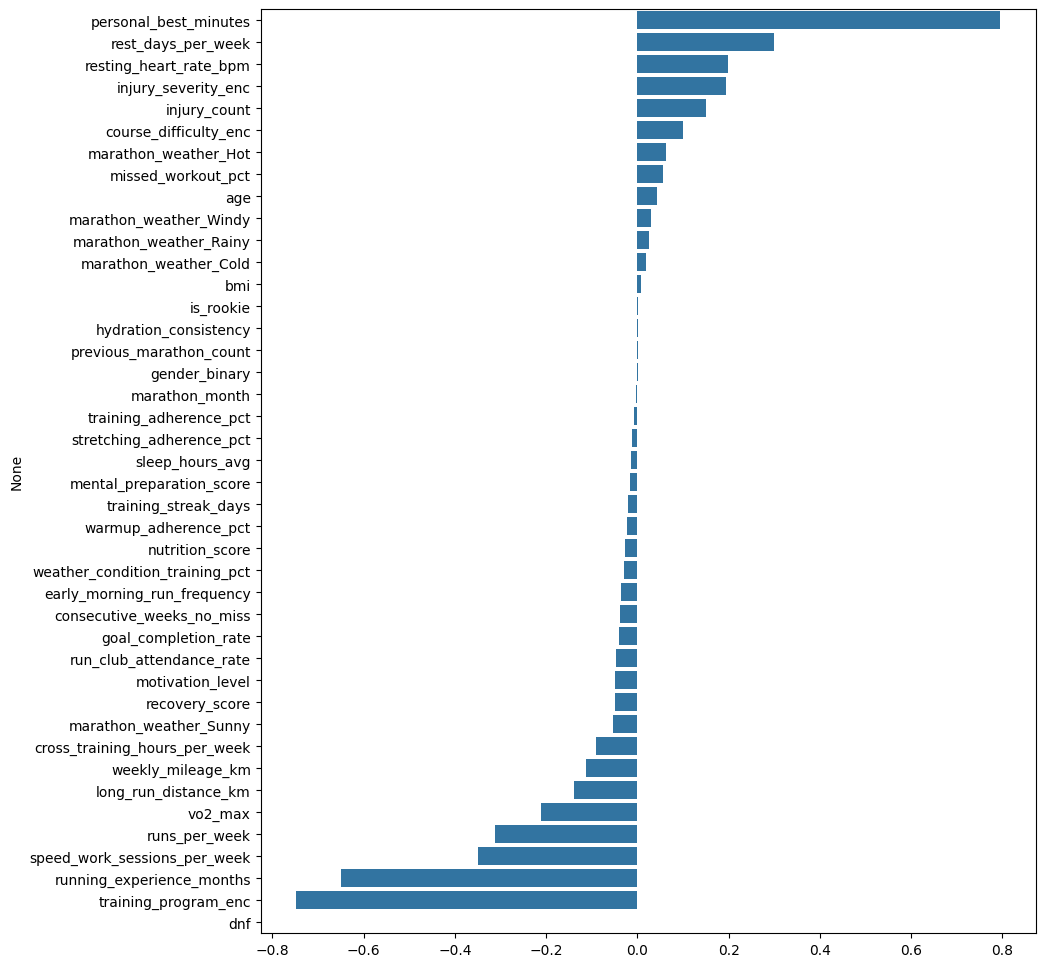

In [52]:
correlations = df_final.corr()['actual_finish_time_minutes'].sort_values(ascending=False)
correlations = correlations.drop('actual_finish_time_minutes')
plt.figure(figsize=(10, 12))
sns.barplot(x=correlations.values, y=correlations.index)

## Model Training

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# Evaluate the model
y_pred = model.predict(X_test)

In [31]:
print(f"Baseline R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test, y_pred):.2f} minutes")

Baseline R2 Score: 0.8178
Baseline MAE: 11.06 minutes


 ## Age between 45-54

In [33]:
df_age_group = df_final[(df_final['age'] >= 45) & (df_final['age'] <= 54)].copy()

In [35]:
len(df_age_group)

16173

In [36]:
X_sub = df_age_group.drop(columns=['actual_finish_time_minutes'])
y_sub = df_age_group['actual_finish_time_minutes']

In [37]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

In [38]:
model_sub = LinearRegression()
model_sub.fit(X_train_s, y_train_s)

y_pred_s = model_sub.predict(X_test_s)

In [42]:
print(f" 45-54 age Baseline R2 Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f" 45-54 age Baseline MAE: {mean_absolute_error(y_test_s, y_pred_s):.2f} minutes")

 45-54 age Baseline R2 Score: 0.8127
 45-54 age Baseline MAE: 11.24 minutes


In [45]:
!git push origin nuri_branch

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 8 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 8.87 KiB | 2.96 MiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:francescosias/MarathonIQ
   4515530..71b87f1  nuri_branch -> nuri_branch
